# Getting Started with Multimodal RAG using LlamaCloud

This notebook demonstrates how to build multimodal RAG applications with LlamaCloud, combining text and image data from documents. We'll show two key patterns:

1. **Screenshot-only retrieval**: Using just images from documents
2. **Combined multimodal retrieval**: Using both text chunks and screenshots together

We use Apple and Tesla 10-K filings which contain both textual information and visual charts/graphs that are perfect for multimodal analysis.

## Setup and Installation

First, let's install the required packages and set up our environment.


In [ ]:
# Install required packages
%pip install "llama-index>=0.13.0<0.14.0" llama-cloud-services
%pip install llama-index-llms-openai llama-index-embeddings-openai

## API Keys Setup

Set your API keys. You'll need:
- **LlamaCloud API Key**: Get from [cloud.llamaindex.ai](https://cloud.llamaindex.ai)
- **OpenAI API Key**: For LLM and embedding models


In [ ]:
import os

# Set your API keys
os.environ["LLAMA_CLOUD_API_KEY"] = ""
os.environ["OPENAI_API_KEY"] = ""

## Data Download

Download Apple and Tesla 10-K filings (2019-2023) for our multimodal analysis examples.

In [ ]:
# Download Apple 10-K filings (2019-2023)
print("Downloading Apple 10-K filings...")
!wget "https://s2.q4cdn.com/470004039/files/doc_earnings/2023/q4/filing/_10-K-Q4-2023-As-Filed.pdf" -O data/apple_2023.pdf
!wget "https://s2.q4cdn.com/470004039/files/doc_financials/2022/q4/_10-K-2022-(As-Filed).pdf" -O data/apple_2022.pdf
!wget "https://s2.q4cdn.com/470004039/files/doc_financials/2021/q4/_10-K-2021-(As-Filed).pdf" -O data/apple_2021.pdf
!wget "https://s2.q4cdn.com/470004039/files/doc_financials/2020/ar/_10-K-2020-(As-Filed).pdf" -O data/apple_2020.pdf
!wget "https://www.dropbox.com/scl/fi/i6vk884ggtq382mu3whfz/apple_2019_10k.pdf?rlkey=eudxh3muxh7kop43ov4bgaj5i&dl=1" -O data/apple_2019.pdf

print("Downloading Tesla 10-K filings...")
# Download Tesla 10-K filings (2019-2023)
!wget "https://ir.tesla.com/_flysystem/s3/sec/000162828024002390/tsla-20231231-gen.pdf" -O data/tesla_2023.pdf
!wget "https://ir.tesla.com/_flysystem/s3/sec/000095017023001409/tsla-20221231-gen.pdf" -O data/tesla_2022.pdf
!wget "https://www.dropbox.com/scl/fi/ptk83fmye7lqr7pz9r6dm/tesla_2021_10k.pdf?rlkey=24kxixeajbw9nru1sd6tg3bye&dl=1" -O data/tesla_2021.pdf
!wget "https://ir.tesla.com/_flysystem/s3/sec/000156459021004599/tsla-10k_20201231-gen.pdf" -O data/tesla_2020.pdf
!wget "https://ir.tesla.com/_flysystem/s3/sec/000156459020004475/tsla-10k_20191231-gen_0.pdf" -O data/tesla_2019.pdf

print("\nDownload complete! Files available:")
!ls -la data/

--2025-09-16 18:19:12--  https://s2.q4cdn.com/470004039/files/doc_earnings/2023/q4/filing/_10-K-Q4-2023-As-Filed.pdf
Resolving s2.q4cdn.com (s2.q4cdn.com)... 2804:391c:0:24:189:1:173:31, 189.1.173.31
Connecting to s2.q4cdn.com (s2.q4cdn.com)|2804:391c:0:24:189:1:173:31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 714094 (697K) [application/pdf]
Saving to: ‘data/apple_2023.pdf’

data/apple_2023.pdf 100%[===================>] 697,36K  3,60MB/s    in 0,2s    

2025-09-16 18:19:15 (3,60 MB/s) - ‘data/apple_2023.pdf’ saved [714094/714094]

--2025-09-16 18:19:15--  https://s2.q4cdn.com/470004039/files/doc_financials/2022/q4/_10-K-2022-(As-Filed).pdf
Resolving s2.q4cdn.com (s2.q4cdn.com)... 189.1.173.31, 2804:391c:0:24:189:1:173:31
Connecting to s2.q4cdn.com (s2.q4cdn.com)|189.1.173.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 729516 (712K) [application/pdf]
Saving to: ‘data/apple_2022.pdf’

data/apple_2022.pdf 100%[================

## LlamaCloudIndex Setup

Connect to an existing LlamaCloudIndex with Apple and Tesla financial documents. The index has been pre-configured with screenshot extraction enabled.

In [ ]:
from llama_cloud_services import LlamaCloudIndex
from llama_cloud import LlamaParseParameters

# create an empty index
# create an empty index
index = await LlamaCloudIndex.acreate_index(
    name="apple_tesla_10k",
    project_name="Default",
    organization_id="04db4a56-04e3-43c5-aef5-0f39f1653dc8",
    llama_parse_parameters=LlamaParseParameters(
        take_screenshot=True  # required to use multimodal RAG
    ),
)

In [ ]:
print(f"Index ID: {index.id}")

Index ID: 426fae88-0c25-4455-95e8-9f58f57f535e


## Multimodal Retrieval Setup

LlamaCloudIndex can retrieve both text chunks and screenshot images from your documents. Let's set up a retriever that captures visual information like charts, tables, and graphs.

In [ ]:
# Create a multimodal retriever that gets both text and screenshot nodes
multimodal_retriever = index.as_retriever(
    dense_similarity_top_k=3,
    sparse_similarity_top_k=3,
    enable_reranking=True,
    rerank_top_n=2,
    retrieve_page_screenshot_nodes=True,  # This enables screenshot retrieval
)

print("✅ Multimodal retriever created - ready to retrieve both text and images!")

✅ Multimodal retriever created - ready to retrieve both text and images!


In [ ]:
# Helper function to display images from retrieved nodes
from PIL import Image
from llama_index.core.schema import ImageNode
from IPython.display import display


def display_image_nodes(nodes):
    """Display images from ImageNode objects"""
    image_nodes = [n for n in nodes if isinstance(n.node, ImageNode)]
    print(f"Found {len(image_nodes)} image nodes:")
    for i, image_node in enumerate(image_nodes):
        print(
            f"\n**Image {i+1}** from {image_node.node.metadata.get('file_name', 'Unknown')}"
        )
        try:
            image = Image.open(image_node.node.resolve_image())
            display(image)
        except Exception as e:
            print(f"Error displaying image: {e}")

In [ ]:
# Multimodal Query Engine setup
from llama_index.core.query_engine import CustomQueryEngine
from llama_index.core.retrievers import BaseRetriever
from llama_index.llms.openai import OpenAI
from llama_index.core.llms import ChatMessage, TextBlock, ImageBlock
from llama_index.core.schema import ImageNode, NodeWithScore, MetadataMode, TextNode
from llama_index.core.prompts import PromptTemplate
from llama_index.core.base.response.schema import Response
from typing import Optional

# Set up the multimodal LLM
gpt_4o = OpenAI(model="gpt-4o", max_new_tokens=4096)

# Prompt template for multimodal queries
MULTIMODAL_PROMPT = """\
You are analyzing financial documents that contain both text and visual elements like charts and tables.

Context from retrieved text and images:
{context_str}

Based on both the text content and any images provided, answer the following question.
Be specific about whether your answer comes from text, images, or both sources.

Question: {query_str}
Answer: """


class MultimodalQueryEngine(CustomQueryEngine):
    """Custom multimodal query engine that processes both text and images."""

    qa_prompt: PromptTemplate
    retriever: BaseRetriever
    multi_modal_llm: OpenAI

    def __init__(self, qa_prompt: Optional[PromptTemplate] = None, **kwargs) -> None:
        super().__init__(
            qa_prompt=qa_prompt or PromptTemplate(MULTIMODAL_PROMPT), **kwargs
        )

    def custom_query(self, query_str: str):
        # Retrieve nodes (both text and image)
        nodes = self.retriever.retrieve(query_str)

        # Separate image and text nodes
        img_nodes = [n for n in nodes if isinstance(n.node, ImageNode)]
        text_nodes = [n for n in nodes if isinstance(n.node, TextNode)]

        # Create context string from text nodes
        context_str = "\n\n".join(
            [r.get_content(metadata_mode=MetadataMode.LLM) for r in text_nodes]
        )

        # Format the prompt
        fmt_prompt = self.qa_prompt.format(context_str=context_str, query_str=query_str)

        # Create image blocks for the multimodal LLM
        img_blocks = [ImageBlock(image=img.node.image) for img in img_nodes]

        # Build the message with both images and text
        messages = [
            ChatMessage(
                role="user", blocks=[*img_blocks, TextBlock(text=str(fmt_prompt))]
            )
        ]

        # Get response from multimodal LLM
        llm_response = self.multi_modal_llm.chat(messages)

        return Response(
            response=str(llm_response),
            source_nodes=nodes,
            metadata={"text_nodes": text_nodes, "image_nodes": img_nodes},
        )


print("✅ Multimodal query engine class ready!")

✅ Multimodal query engine class ready!


## Example 1: Screenshot-Only Query

This example shows how to work with just the visual/image content from documents, ignoring text.

In [ ]:
# Create a screenshot-only query engine
class ScreenshotOnlyQueryEngine(CustomQueryEngine):
    """Query engine that only uses screenshot images, ignoring text."""

    retriever: BaseRetriever
    multi_modal_llm: OpenAI

    def custom_query(self, query_str: str):
        # Retrieve nodes
        nodes = self.retriever.retrieve(query_str)

        # Keep only image nodes
        img_nodes = [n for n in nodes if isinstance(n.node, ImageNode)]

        if not img_nodes:
            return Response(
                response="No images found for this query.",
                source_nodes=[],
                metadata={"image_nodes": []},
            )

        # Create image blocks
        img_blocks = [ImageBlock(image=img.node.image) for img in img_nodes]

        # Simple prompt for image-only analysis
        prompt = f"""\
Analyze these screenshots from financial documents to answer the question: {query_str}

Focus only on the visual information presented in the images (charts, tables, graphs, etc.).
Be specific about what you can see in the images.
"""

        messages = [
            ChatMessage(role="user", blocks=[*img_blocks, TextBlock(text=prompt)])
        ]

        llm_response = self.multi_modal_llm.chat(messages)

        return Response(
            response=str(llm_response),
            source_nodes=img_nodes,
            metadata={"image_nodes": img_nodes},
        )


# Create the screenshot-only query engine
screenshot_engine = ScreenshotOnlyQueryEngine(
    retriever=multimodal_retriever, multi_modal_llm=gpt_4o
)

print("✅ Screenshot-only query engine ready!")

✅ Screenshot-only query engine ready!


🔍 **Query:** Show me Apple's stock performance comparison chart

📸 **Screenshot-only response:**
assistant: The screenshots show Apple's stock performance comparison charts from two different financial documents.

### 2022 Chart:
- **Time Frame:** September 29, 2017, to September 24, 2022.
- **Comparison Indices:** 
  - Apple Inc.
  - S&P 500 Index
  - S&P Information Technology Index
  - Dow Jones U.S. Technology Supersector Index
- **Performance:**
  - Apple Inc. shows a significant increase, reaching approximately $411.
  - S&P 500 Index ends at $156.
  - S&P Information Technology Index ends at $217.
  - Dow Jones U.S. Technology Supersector Index ends at $209.

### 2020 Chart:
- **Time Frame:** September 25, 2015, to September 26, 2020.
- **Comparison Indices:**
  - Apple Inc.
  - S&P 500 Index
  - S&P Information Technology Index
  - Dow Jones U.S. Technology Supersector Index
- **Performance:**
  - Apple Inc. shows a steep increase, reaching approximately $424.
  - S&P 500 Index

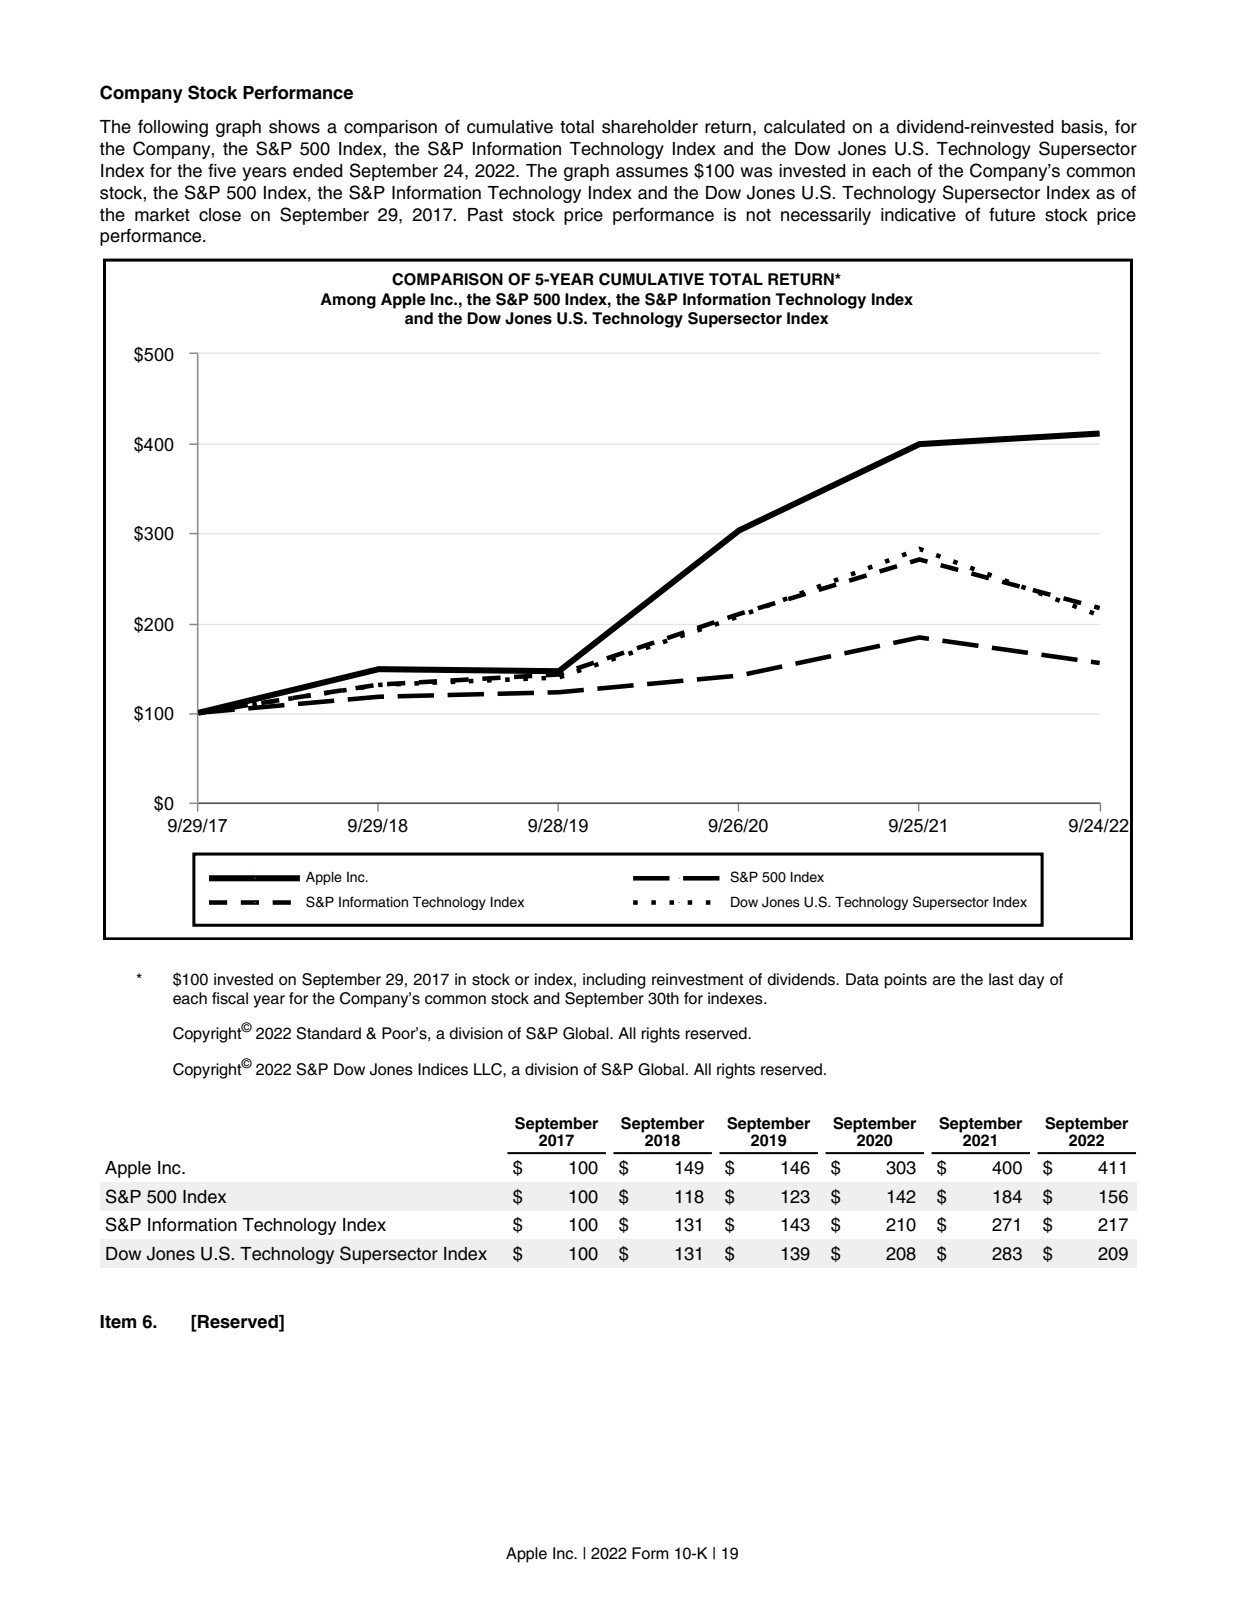


**Image 2** from apple_2020.pdf


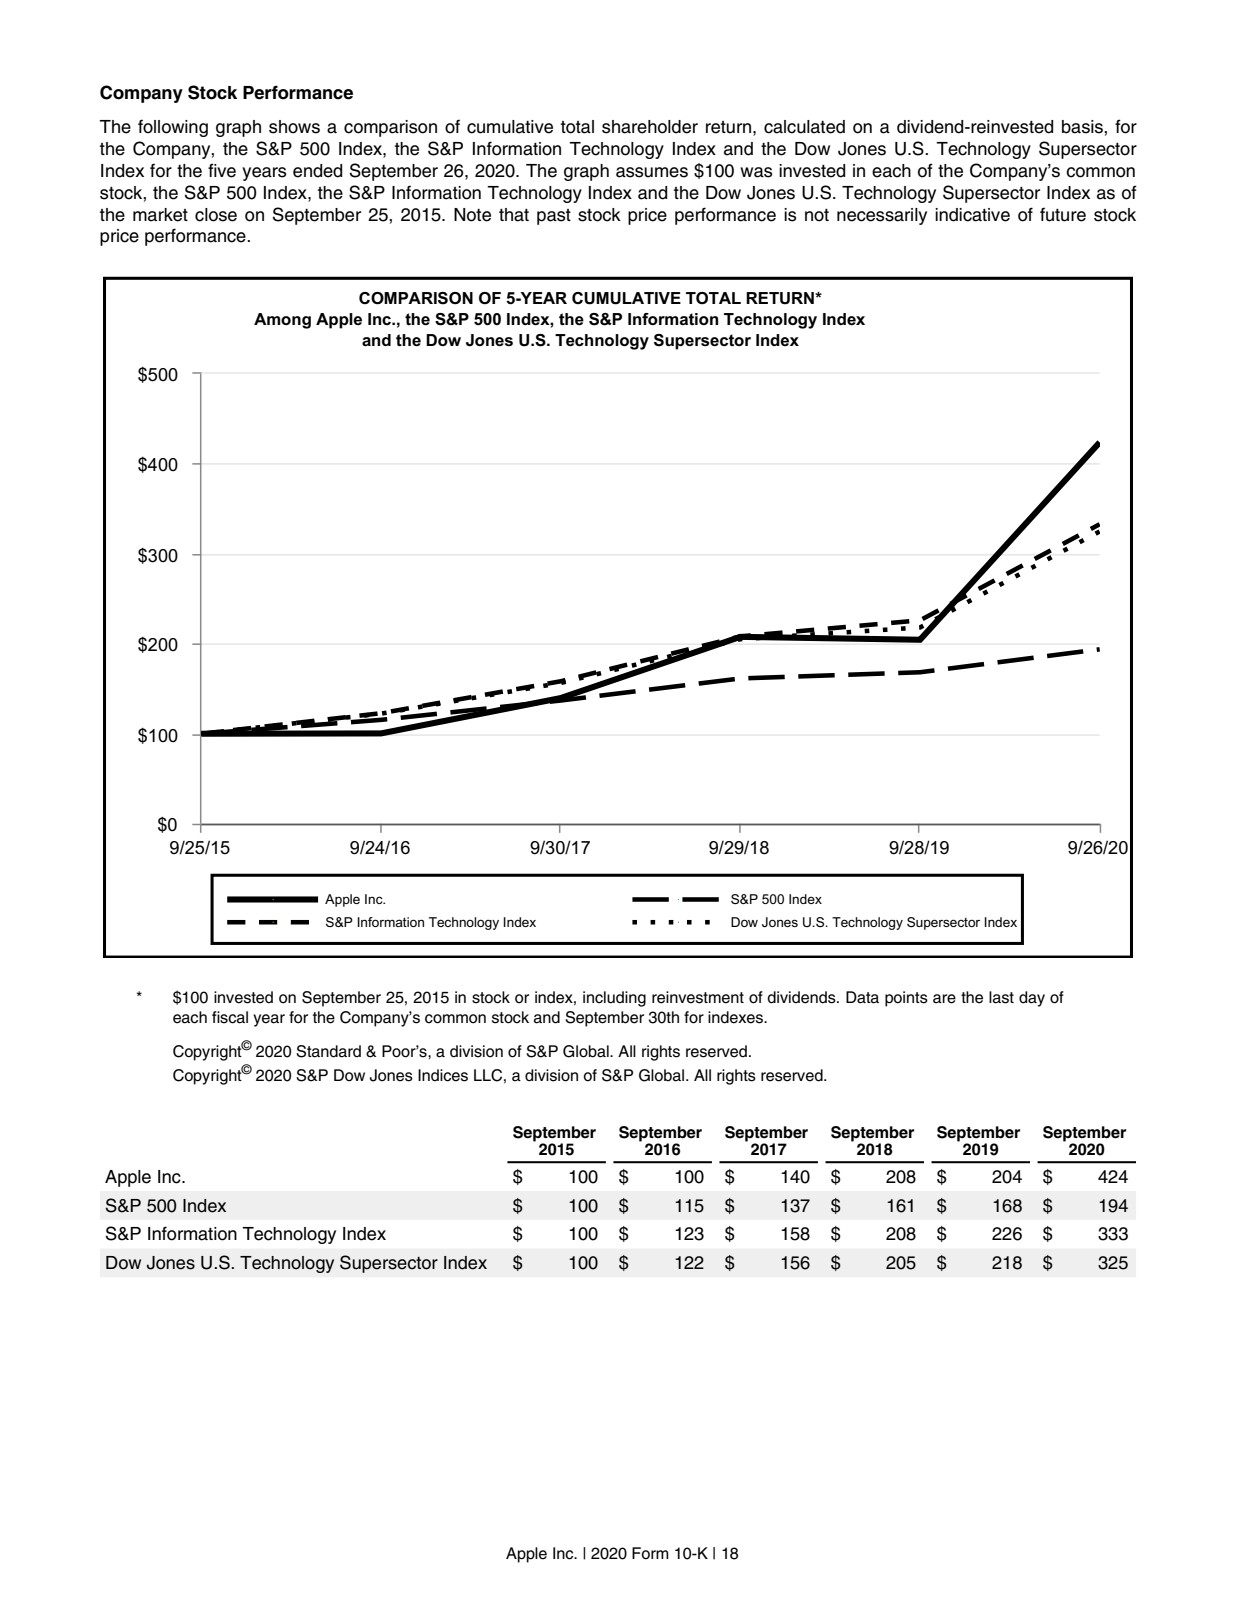

In [ ]:
## Test the screenshot-only query engine

query = "Show me Apple's stock performance comparison chart"

print(f"🔍 **Query:** {query}")
print("\n📸 **Screenshot-only response:**")

response = screenshot_engine.query(query)
print(response.response)

print(f"\n📊 **Retrieved {len(response.metadata['image_nodes'])} images:**")
display_image_nodes(response.source_nodes)

## Example 2: Combined Text + Screenshot Query

This example shows how to use both text content and images together for richer analysis.

In [ ]:
# Create the combined multimodal query engine
combined_engine = MultimodalQueryEngine(
    retriever=multimodal_retriever, multi_modal_llm=gpt_4o
)

print("✅ Combined multimodal query engine ready!")

✅ Combined multimodal query engine ready!


🔍 **Query:** Analyze Apple's 5-year cumulative total return performance compared to market indices

🔄 **Combined multimodal response:**
assistant: Based on the information from both the text and images, here's an analysis of Apple's 5-year cumulative total return performance compared to market indices:

### 2022 Data (from the first document):
- **Apple Inc.**: Started at $100 in 2017 and grew to $411 by 2022.
- **S&P 500 Index**: Started at $100 and grew to $156.
- **S&P Information Technology Index**: Started at $100 and grew to $217.
- **Dow Jones U.S. Technology Supersector Index**: Started at $100 and grew to $209.

### 2019 Data (from the second document):
- **Apple Inc.**: Started at $100 in 2014 and grew to $237 by 2019.
- **S&P 500 Index**: Started at $100 and grew to $167.
- **S&P Information Technology Index**: Started at $100 and grew to $231.
- **Dow Jones U.S. Technology Supersector Index**: Started at $100 and grew to $218.

### Analysis:
- **Apple's Performance**: In bo

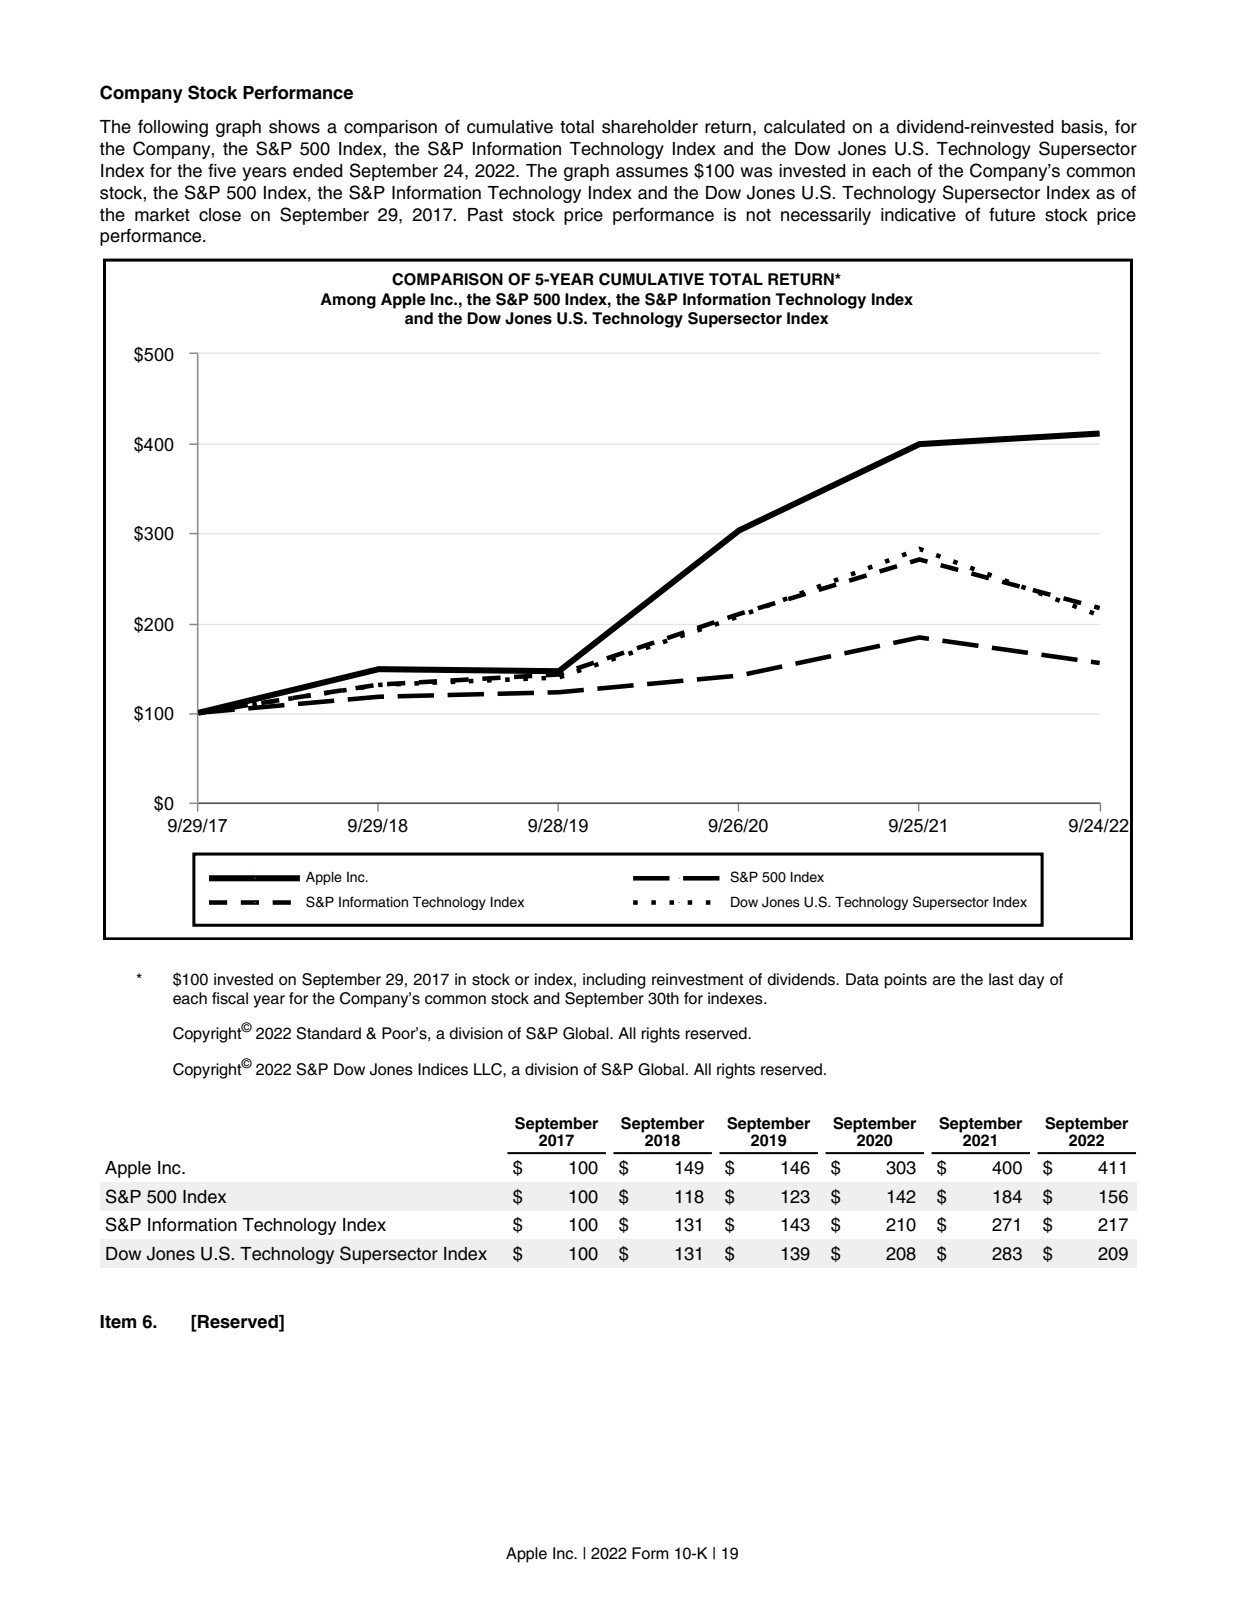


**Image 2** from apple_2019.pdf


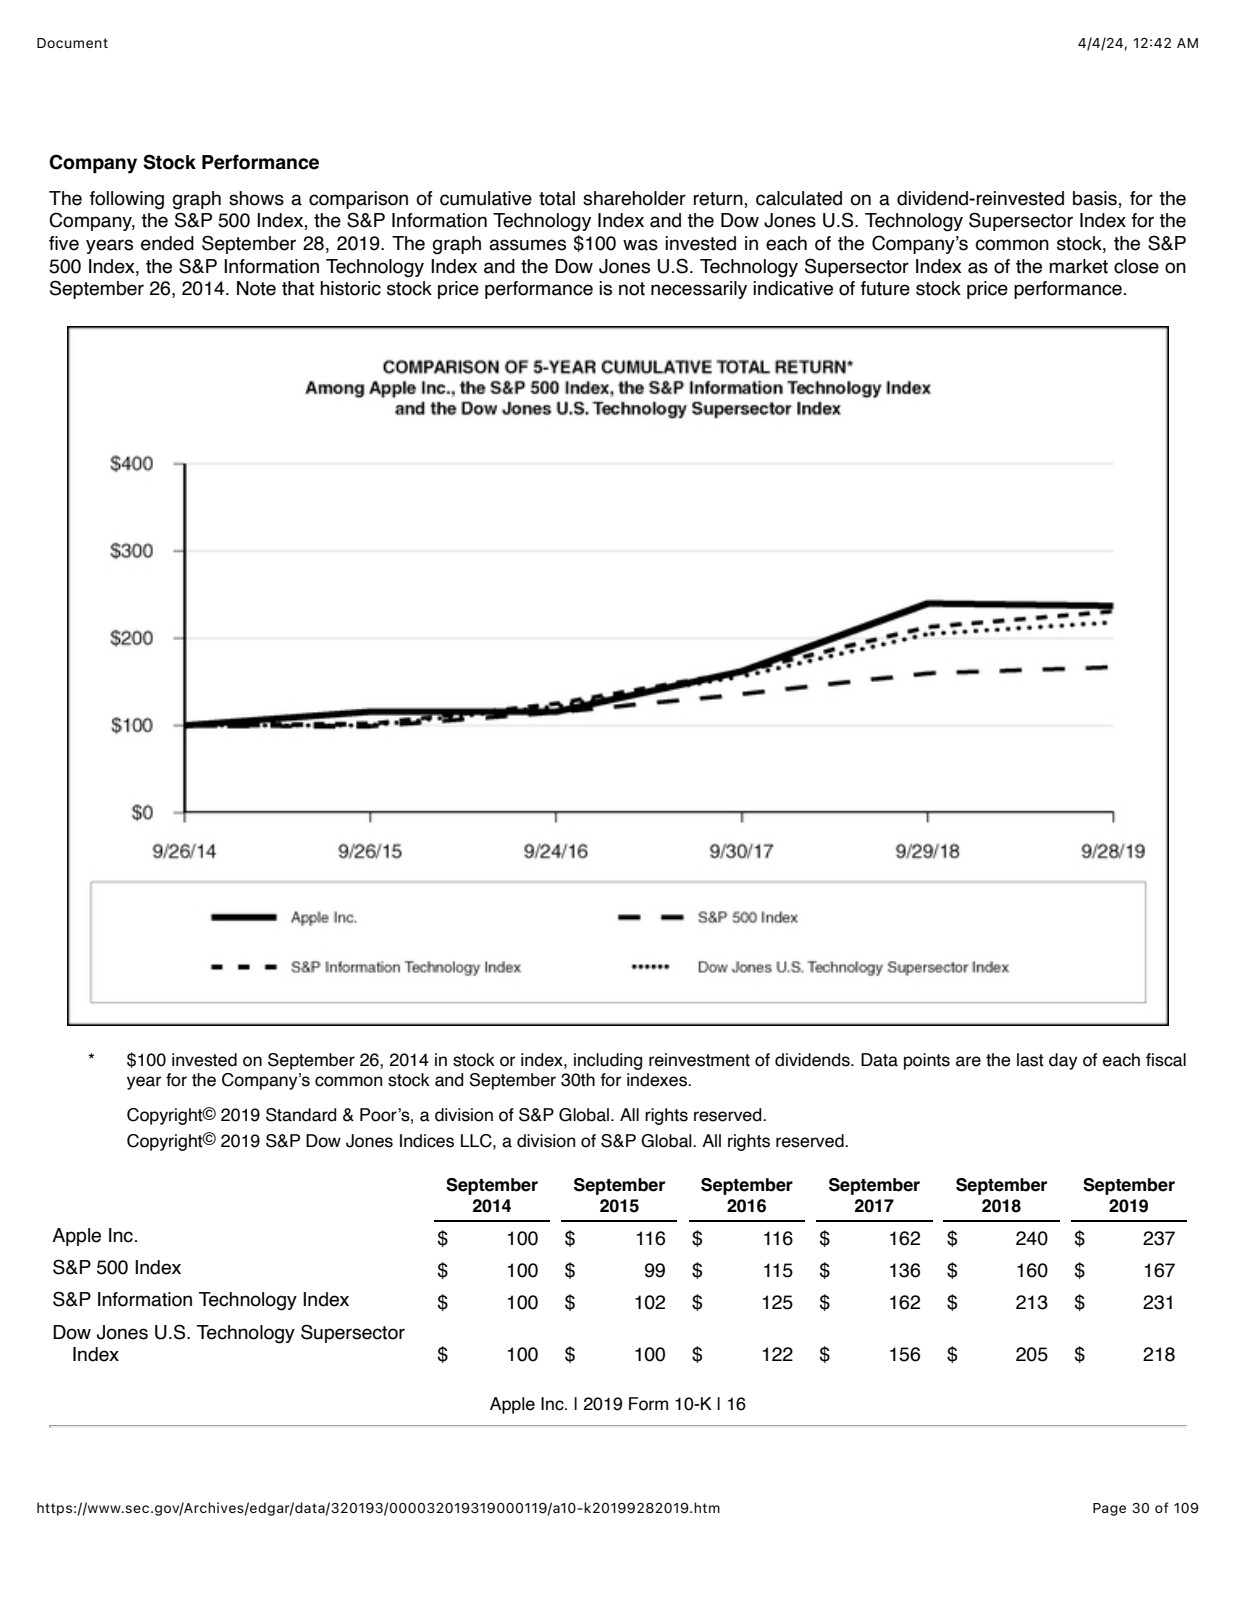

In [ ]:
# Test the combined multimodal query engine
query = "Analyze Apple's 5-year cumulative total return performance compared to market indices"

print(f"🔍 **Query:** {query}")
print("\n🔄 **Combined multimodal response:**")

response = combined_engine.query(query)
print(response.response)

print(f"\n📊 **Retrieved sources:**")
print(f"- Text nodes: {len(response.metadata['text_nodes'])}")
print(f"- Image nodes: {len(response.metadata['image_nodes'])}")

print("\n**Images:**")
display_image_nodes(response.source_nodes)

## Summary

This notebook demonstrated two key multimodal RAG patterns with LlamaCloudIndex:

### 🖼️ Screenshot-Only Pattern
- **Use case**: When you need to analyze visual elements (charts, tables, graphs) without text context
- **Implementation**: Filter retrieved nodes to keep only `ImageNode` objects
- **Example**: Asking for specific charts or visual comparisons

### 🔄 Combined Multimodal Pattern  
- **Use case**: When you need both visual and textual information for comprehensive analysis
- **Implementation**: Use both `TextNode` and `ImageNode` objects together
- **Example**: Complex financial analysis combining narrative text with supporting charts

### Key Benefits
- **Visual Understanding**: GPT-4V can interpret charts, tables, and graphs directly
- **Rich Context**: Combining text and images provides more complete answers
- **Flexible Retrieval**: LlamaCloudIndex automatically captures screenshots during parsing

### Next Steps
- Experiment with different document types (reports, presentations, etc.)
- Try various multimodal queries on your own documents
- Explore advanced retrieval parameters for better image-text matching